# **Breaking SAT CAPTCHAs with Machine Learning**
_Alfredo Villasenor-Monsivais_<br>
_Alejandra G. Silva-Trujillo_<br>
_Juan C. Cuevas-Tello_

#### **Necessary imports:**

In [11]:
import time
import re
import base64
import os
import pyperclip
import numpy as np
import pandas as pd
from datetime import datetime
from io import BytesIO
from PIL import Image, ImageDraw
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from twocaptcha import TwoCaptcha
from IPython.display import display, clear_output
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

In [2]:
# Configurar opciones para ejecutar en segundo plano (headless)
firefox_options = Options()
firefox_options.add_argument("--headless")  # Modo sin interfaz gráfica

# Inicializar WebDriver con opciones
driver = webdriver.Firefox(options=firefox_options)

# Acceder a la página (sin abrir ventana)
driver.get("https://login.siat.sat.gob.mx/nidp/app/")
print("WebDriver inicializado.")

# Configurar 2Captcha
solver = TwoCaptcha('a04de98e78dd8976ba65b1a7300d461a')

# Obtener la fecha actual en formato DD-MM-YYYY
fecha_actual = datetime.now().strftime("%d-%m-%Y")

# Crear la carpeta si no existe
os.makedirs(fecha_actual, exist_ok=True)

# Definir la ruta del archivo temporal
temp_filename = os.path.join(fecha_actual, "temp_captcha.png")

for i in range(13):
    clear_output(wait=True)  # Limpiar la salida de la celda
    driver.refresh()  # Refrescar la página para obtener un nuevo CAPTCHA

    # Manejar posibles alertas
    try:
        alert = driver.switch_to.alert
        alert.accept()
    except Exception:
        pass

    time.sleep(4)  # Esperar a que se genere el CAPTCHA

    # Obtener el código fuente de la página
    page_source = driver.page_source
    
    # Buscar la imagen CAPTCHA en base64
    match = re.search(r'<img src="data:image/jpeg;base64,([^"]+)"', page_source)

    if match:
        base64_string = match.group(1)
        image_data = base64.b64decode(base64_string)
        image = Image.open(BytesIO(image_data))
        
        print(f"CAPTCHA #{i+1}:")
        display(image)

        # Guardar temporalmente la imagen en la carpeta
        image.save(temp_filename)

        # Esperar hasta recibir una respuesta válida de 2Captcha
        captcha_code = None
        print("Esperando respuesta de 2Captcha...")
        while not captcha_code:  # No se avanza hasta obtener una respuesta
            try:
                result = solver.normal(temp_filename, numeric=4, minLen=6, maxLen=6)  # Resolver el CAPTCHA
                captcha_id = result.get("captchaId")  # Obtener el id del captcha
                captcha_code = result.get("code", "").upper()  # Convertir a mayúsculas
            except Exception as e:
                print(f"Error capturado: {e}")
                time.sleep(3)  # Esperar 3 segundos antes de intentar de nuevo

        print(f"Respuesta: {captcha_code}")
        time.sleep(1)
        # Confirmar si la respuesta es correcta
        validacion = input("¿La respuesta es correcta? (s/n): ").strip().lower()

        if validacion == "s":
            solver.report(captcha_id, True)  # Reportar como correcta
        else:
            solver.report(captcha_id, False)  # Reportar como incorrecta

            # Permitir al usuario corregir el CAPTCHA manualmente
            pyperclip.copy(captcha_code)
            captcha_code = input(f"Corrige el CAPTCHA: ").strip().upper()

        # Guardar la imagen con el nombre en mayúsculas
        final_filename = os.path.join(fecha_actual, f"{captcha_code}.png")
        image.save(final_filename)

# Cerrar el WebDriver
driver.quit()
clear_output(wait=True)
print("WebDriver cerrado.")

# Eliminar el archivo temporal después de finalizar
if os.path.exists(temp_filename):
    os.remove(temp_filename)

WebDriver cerrado.


In [ ]:
# folder_path = "04-04-2025/"
output_csv = "dataset.csv"

# Coordenadas fijas para cada caracter dentro de un captcha
coords = [
    (0, 5, 27, 32),
    (25, 16, 52, 43),
    (50, 5, 77, 32),
    (75, 16, 102, 43),
    (100, 5, 127, 32),
    (125, 16, 152, 43)
]

data = []

for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        # Extraer texto del nombre de archivo sin extensión
        text = os.path.splitext(filename)[0]
        
        # Abrir imagen
        image = Image.open(os.path.join(folder_path, filename)).convert("L")

        # Por cada caracter a recortar
        for i, coord in enumerate(coords):
            if i < len(text):  # Asegurarse de que exista ese caracter
                label = text[i]
                char = image.crop(coord)
                array = np.array(char).flatten()

                #  # Reconstruir imagen desde el vector
                # img_from_vector = Image.fromarray(array.reshape(27, 27).astype(np.uint8))
                # display(img_from_vector)  # Mostrar imagen reconstruida
                
                # Guardar fila: [label, pixel0, pixel1, ..., pixel728]
                data.append([label] + array.tolist())

# Columnas: label + pixeles
columns = ["label"] + [f'px{i}' for i in range(27*27)]

new_df = pd.DataFrame(data, columns=columns)

# Si el CSV existe, cargarlo y concatenar
if os.path.exists(output_csv):
    old_df = pd.read_csv(output_csv)
    df = pd.concat([old_df, new_df], ignore_index=True)
else:
    df = new_df

# Guardar CSV final
df.to_csv("dataset.csv", index=False)

C:\Users\Alfredo\AppData\Local\Temp\ipykernel_15548\2495477839.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", edgecolor="black")


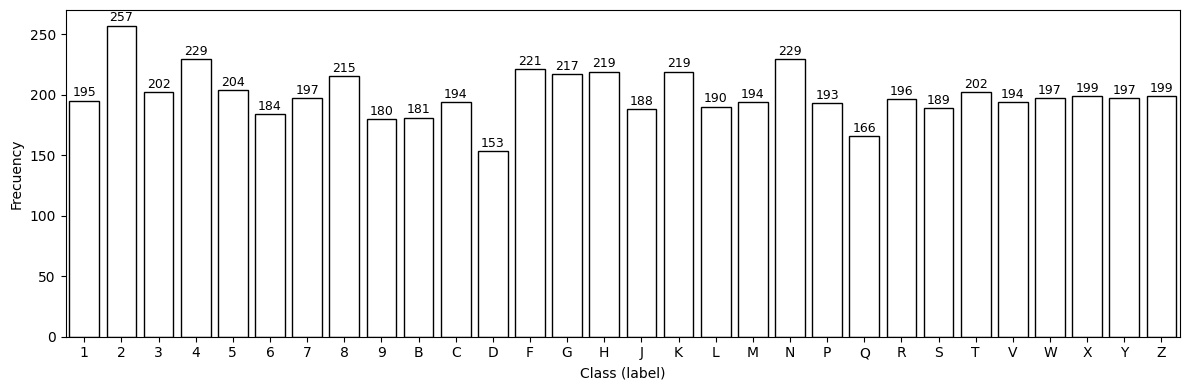

Clases válidas (0-9 y A-Z): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Clases encontradas en el dataset: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'B', 'C', 'D', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y', 'Z']
Clases no válidas (fuera de 0-9 y A-Z): ['0', 'A', 'E', 'I', 'O', 'U']
label
1    195
2    257
3    202
4    229
5    204
6    184
7    197
8    215
9    180
B    181
C    194
D    153
F    221
G    217
H    219
J    188
K    219
L    190
M    194
N    229
P    193
Q    166
R    196
S    189
T    202
V    194
W    197
X    199
Y    197
Z    199
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import string

# Cargar dataset
df = pd.read_csv("dataset.csv")

# Contar las ocurrencias de cada clase (label)
class_counts = df['label'].value_counts().sort_index()  # Ordenar alfabéticamente

# Graficar la distribución de clases
plt.figure(figsize=(12, 4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", edgecolor="black")

# Agregar rayas diagonales a las barras (sin relleno)
for patch in ax.patches:
    count = int(patch.get_height())
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height() + 1  # un poco arriba de la barra
    ax.text(x, y, count, ha='center', va='bottom', fontsize=9)
    patch.set_facecolor('none')  # Eliminar el relleno (transparente)
    patch.set_edgecolor('black')  # Borde negro
    # patch.set_hatch('///')  # Establecer rayas diagonales

plt.xlabel("Class (label)")
plt.ylabel("Frecuency")
# plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=300, bbox_inches='tight')
plt.show()

clases_validas = list(string.digits) + list(string.ascii_uppercase)
clases_encontradas = sorted(df['label'].unique())
clases_no_validas = [c for c in clases_validas if c not in clases_encontradas]

print("Clases válidas (0-9 y A-Z):", clases_validas)
print("Clases encontradas en el dataset:", clases_encontradas)
print("Clases no válidas (fuera de 0-9 y A-Z):", clases_no_validas)

print(class_counts)

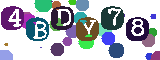

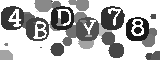

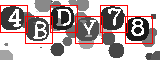

In [28]:
from PIL import Image, ImageDraw

# Cargar imagen original
imagen = Image.open("example/4BDY78.png")
display(imagen)

imagen = imagen.convert("L")
display(imagen)

# Definir coordenadas de recortes
rectangulos = [
    (0, 5, 27, 32),
    (25, 16, 52, 43),
    (50, 5, 77, 32),
    (75, 16, 102, 43),
    (100, 5, 127, 32),
    (125, 16, 152, 43)
]

# Recortar cada sección
recortes = [imagen.crop(coords) for coords in rectangulos]

imagen_rgb = imagen.convert("RGB")

# Dibujar rectángulos en la imagen original
dibujar = ImageDraw.Draw(imagen_rgb)
for coords in rectangulos:
    dibujar.rectangle(coords, outline="red", width=1)  # Rectángulo rojo

display(imagen_rgb)

# Obtener dimensiones individuales de los recortes
ancho_recorte, alto_recorte = recortes[0].size
num_recortes = len(recortes)

espaciado = 15  # separación entre recortes en píxeles

# Calcular ancho total considerando separación
ancho_total = num_recortes * ancho_recorte + (num_recortes - 1) * espaciado
alto_total = alto_recorte

# Crear nueva imagen para unir todos los recortes horizontalmente
imagen_unida = Image.new("RGB", (ancho_total, alto_total), color="white")

# Pegar cada recorte en la imagen nueva
for i, recorte in enumerate(recortes):
    x = i * (ancho_recorte + espaciado)
    imagen_unida.paste(recorte, (x, 0))

# Mostrar imagen resultante
display(imagen_unida)

In [32]:
modelo = load_model("cnn_model.h5")

clases = ['1', '2', '3', '4', '5', '6', '7', '8', '9',
          'B', 'C', 'D', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N',
          'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y', 'Z']

le = LabelEncoder()
le.fit(clases)

LabelEncoder()

WebDriver inicializado.
CAPTCHA #1:


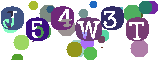

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Texto del CAPTCHA predicho: J54W3T
CAPTCHA #2:


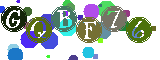

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Texto del CAPTCHA predicho: GQBF76
CAPTCHA #3:


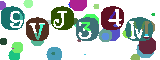

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Texto del CAPTCHA predicho: 9VJ34M
WebDriver cerrado.


In [33]:
# Configurar opciones para ejecutar en segundo plano (headless)
firefox_options = Options()
firefox_options.add_argument("--headless")  # Modo sin interfaz gráfica

# Inicializar WebDriver con opciones
driver = webdriver.Firefox(options=firefox_options)

# Acceder a la página (sin abrir ventana)
driver.get("https://login.siat.sat.gob.mx/nidp/app/")
print("WebDriver inicializado.")

for i in range(3):
    driver.refresh()  # Refrescar la página para obtener un nuevo CAPTCHA

    # Manejar posibles alertas
    try:
        alert = driver.switch_to.alert
        alert.accept()
    except Exception:
        pass

    time.sleep(4)  # Esperar a que se genere el CAPTCHA

    # Obtener el código fuente de la página
    page_source = driver.page_source
    
    # Buscar la imagen CAPTCHA en base64
    match = re.search(r'<img src="data:image/jpeg;base64,([^"]+)"', page_source)

    if match:
        base64_string = match.group(1)
        image_data = base64.b64decode(base64_string)
        image = Image.open(BytesIO(image_data))
        
        print(f"CAPTCHA #{i+1}:")
        display(image)

        # imagen = imagen.convert("L")

        # Definir coordenadas de los recortes (x_inicio, y_inicio, x_fin, y_fin)
        rectangulos = [
            (0, 5, 27, 32),  # Primer recorte
            (25, 16, 52, 43),   # Segundo recorte
            (50, 5, 77, 32),
            (75, 16, 102, 43),
            (100, 5, 127, 32),
            (125, 16, 152, 43)
        ]

        predictions = []

        # Recortar y guardar cada sección
        for i, coords in enumerate(rectangulos):
            recorte = image.crop(coords)

            # Convertir recorte a escala de grises
            recorte = recorte.convert("L")

            # Convertir a array normalizado y reshape a (1, 27, 27, 1)
            recorte_array = np.array(recorte).astype("float32") / 255.0
            recorte_array = recorte_array.reshape(1, 27, 27, 1)

            # Predicción
            pred = modelo.predict(recorte_array)
            label_index = np.argmax(pred)
            predicted_label = le.inverse_transform([label_index])[0]

            predictions.append(predicted_label)
        
        captcha_string = "".join(predictions)
        print("Texto del CAPTCHA predicho:", captcha_string)

# Cerrar el WebDriver
driver.quit()
print("WebDriver cerrado.")

In [44]:
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.common.by import By
import base64
import re
import time
from PIL import Image
from io import BytesIO
import numpy as np

# Configurar opciones para ejecutar en segundo plano (headless)
firefox_options = Options()

# Inicializar WebDriver con opciones
driver = webdriver.Firefox(options=firefox_options)

# Acceder a la página (sin abrir ventana)
driver.get("https://login.siat.sat.gob.mx/nidp/app/")

time.sleep(4)  # Esperar a que se genere el CAPTCHA

# Obtener el código fuente de la página
page_source = driver.page_source

# Buscar la imagen CAPTCHA en base64
match = re.search(r'<img src="data:image/jpeg;base64,([^"]+)"', page_source)

if match:
    base64_string = match.group(1)
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))

    # Definir coordenadas de los recortes (x_inicio, y_inicio, x_fin, y_fin)
    rectangulos = [
        (0, 5, 27, 32),  # Primer recorte
        (25, 16, 52, 43),   # Segundo recorte
        (50, 5, 77, 32),
        (75, 16, 102, 43),
        (100, 5, 127, 32),
        (125, 16, 152, 43)
    ]

    predictions = []

    # Recortar y guardar cada sección
    for i, coords in enumerate(rectangulos):
        recorte = image.crop(coords)

        # Convertir recorte a escala de grises
        recorte = recorte.convert("L")

        # Convertir a array normalizado y reshape a (1, 27, 27, 1)
        recorte_array = np.array(recorte).astype("float32") / 255.0
        recorte_array = recorte_array.reshape(1, 27, 27, 1)

        # Predicción
        pred = modelo.predict(recorte_array)
        label_index = np.argmax(pred)
        predicted_label = le.inverse_transform([label_index])[0]

        predictions.append(predicted_label)
    
    captcha_string = "".join(predictions)

    # Escribir en el input con id "userCaptcha"
    input_captcha = driver.find_element(By.ID, "userCaptcha")
    input_captcha.clear()
    input_captcha.send_keys(captcha_string)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#### **Load and Pre-process the dataset:**

In [ ]:
df = pd.read_csv('dataset.csv')

X = df.drop(columns=["label"]).values.astype("float32")
y = df["label"].values
X /= 255.0

X = X.reshape(-1, 27, 27, 1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, stratify=y_encoded, random_state=42)

In [ ]:
n = 6

plt.figure(figsize=(12, 2))

for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(X_train[i].reshape(27, 27), cmap='gray')
    label_index = np.argmax(y_train[i])  # one-hot → índice
    plt.title(le.inverse_transform([label_index])[0])  # índice → etiqueta
    plt.axis("off")

plt.tight_layout()
plt.show()

#### **Model architecture:**

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(27, 27, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

#### **Train and Save the model:**

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

model.summary()

In [ ]:
model.save("cnn_model.h5")

hist_df = pd.DataFrame(history.history)
hist_df.to_csv("cnn_training_history.csv", index=False)

#### **Show the model history graphs:**

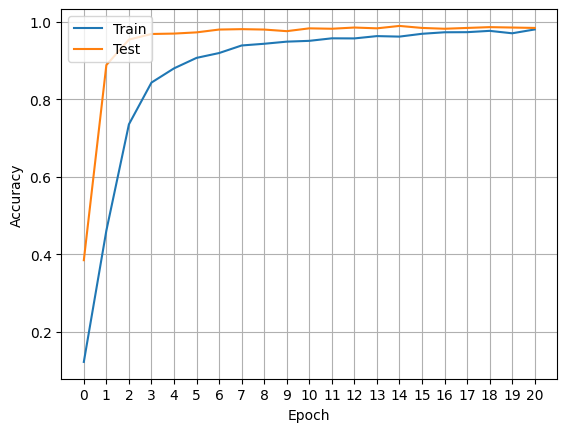

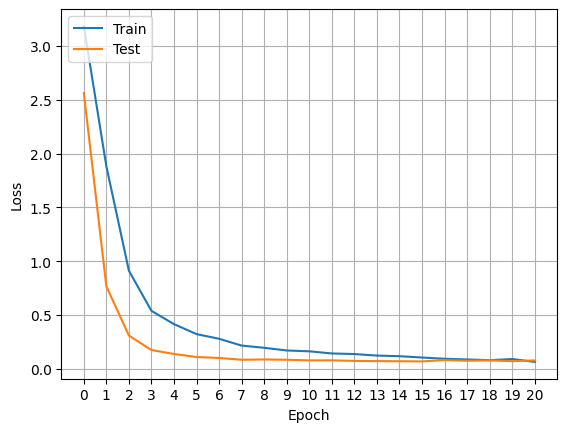

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("cnn_training_history.csv")

epochs = list(range(len(history)))

plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(epochs)
plt.legend(['Train', 'Test'], loc='upper left')
plt.grid()
plt.show()

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(epochs)
plt.legend(['Train', 'Test'], loc='upper left')
plt.grid()
plt.show()

#### **Make the test set predictions and show the confusion matrix:**

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy on test set: 0.9925


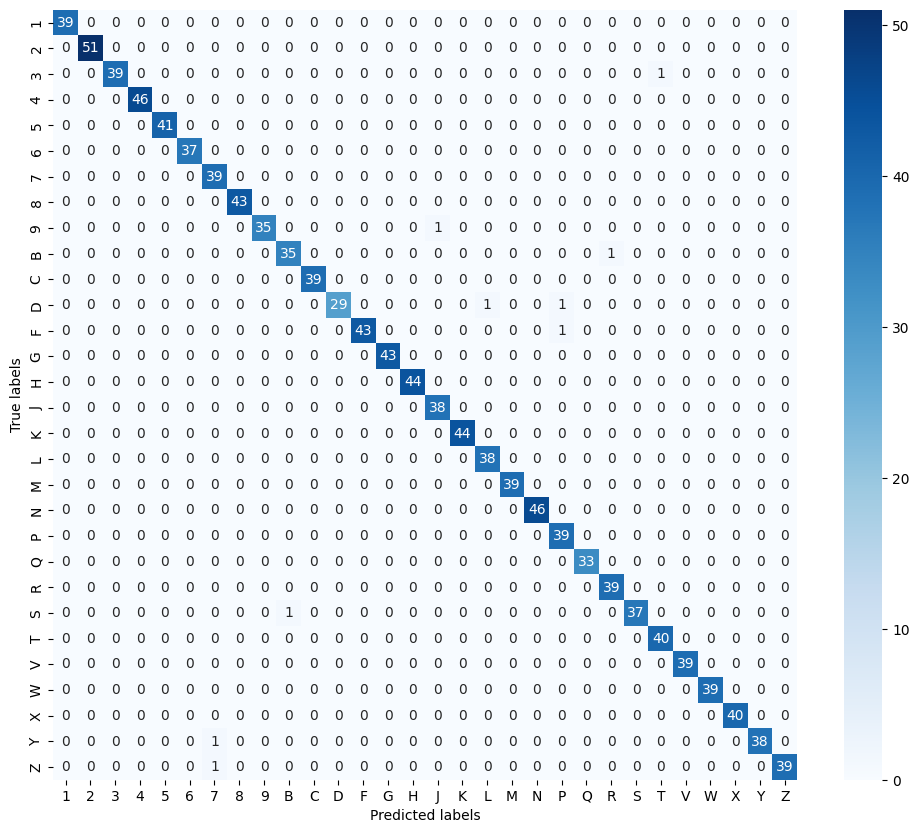

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score

model = load_model("cnn_model.h5")

predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy on test set: {accuracy:.4f}")

class_names = le.classes_
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.yticks(rotation=90)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()